# Heart disease Analysis or Cardiovascular disease analysis

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('02 septmber\7\5th,6th\5th,6th\EDA_project'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

%matplotlib inline
sns.set(style = 'whitegrid')

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r'D:\Data Science Full Stack\02 septmber\7\5th,6th\5th,6th\EDA_project\heart.csv')

In [5]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [6]:
print('The shape of the data set : ', df.shape)

The shape of the data set :  (303, 14)


In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [14]:
df['target'].nunique()

2

In [15]:
df['target'].unique()

array([1, 0])

In [16]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

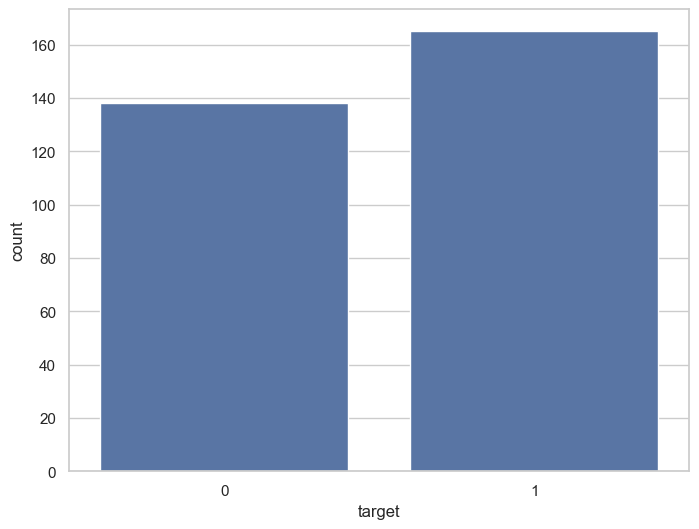

In [17]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="target", data=df)
plt.show()

In [18]:
df.groupby('sex')['target'].value_counts()

sex  target
0    1          72
     0          24
1    0         114
     1          93
Name: count, dtype: int64

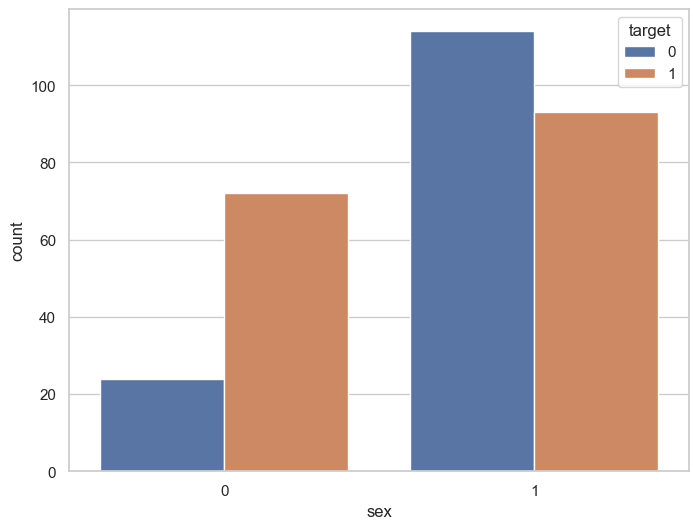

In [19]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="sex", hue="target", data=df)
plt.show()

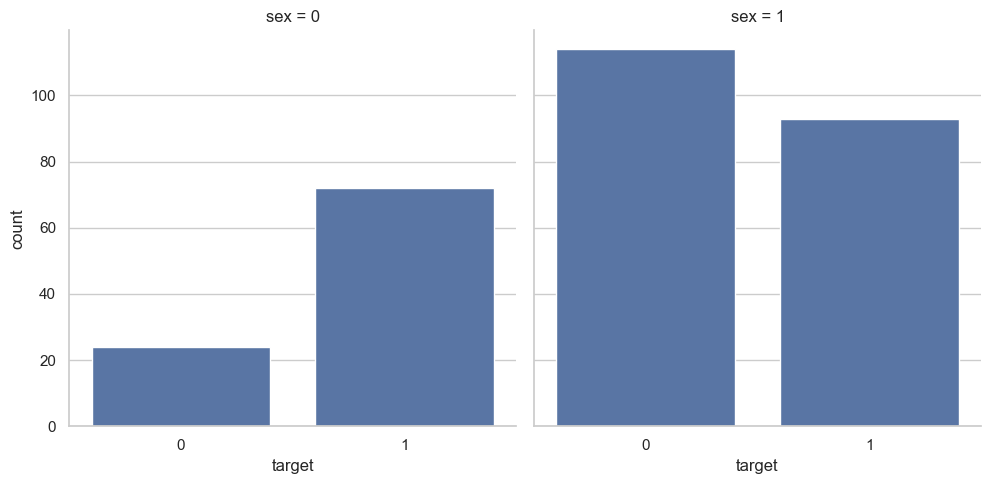

In [20]:
ax = sns.catplot(x="target", col="sex", data=df, kind="count", height=5, aspect=1)

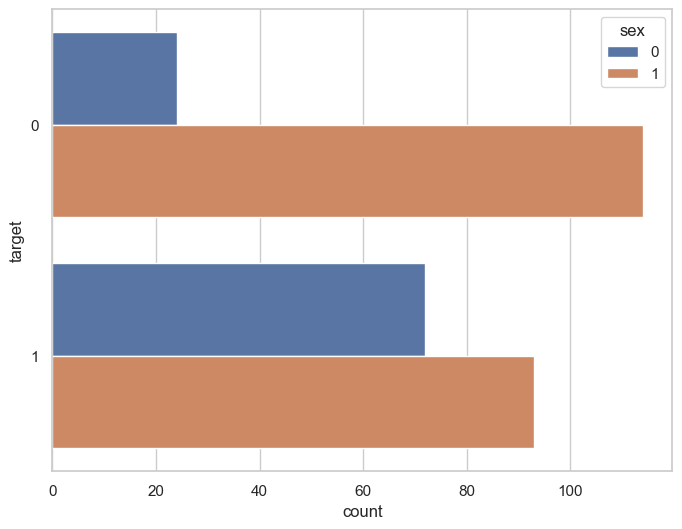

In [21]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(y="target", hue="sex", data=df)
plt.show()

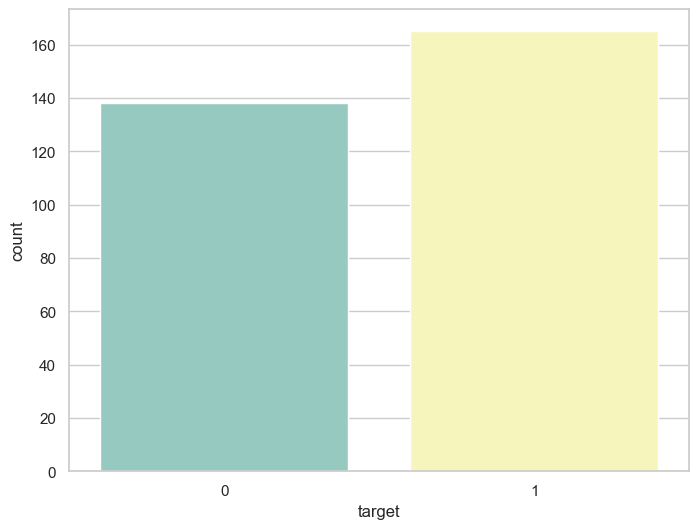

In [22]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="target", data=df, palette="Set3")
plt.show()

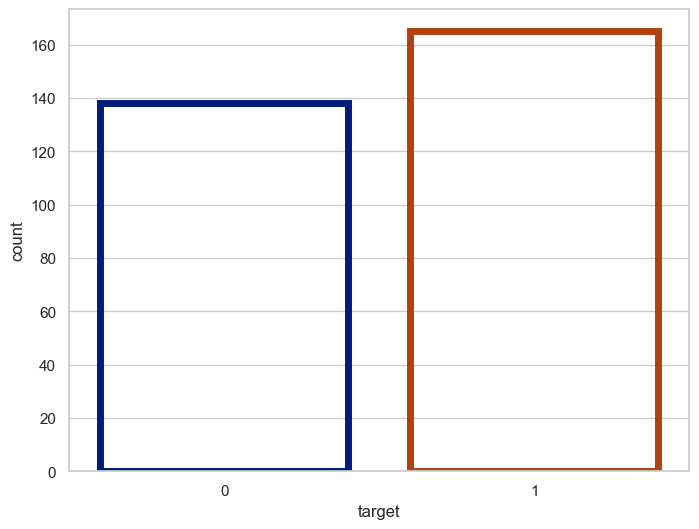

In [23]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="target", data=df, facecolor=(0, 0, 0, 0), linewidth=5, edgecolor=sns.color_palette("dark", 3))
plt.show()

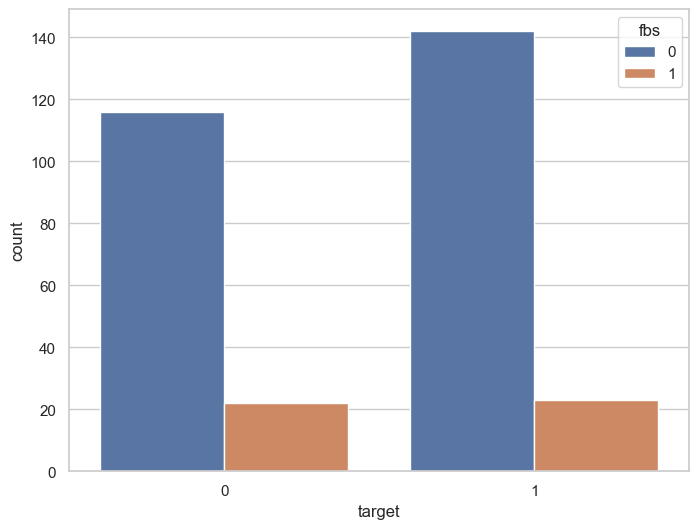

In [24]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="target", hue="fbs", data=df)
plt.show()

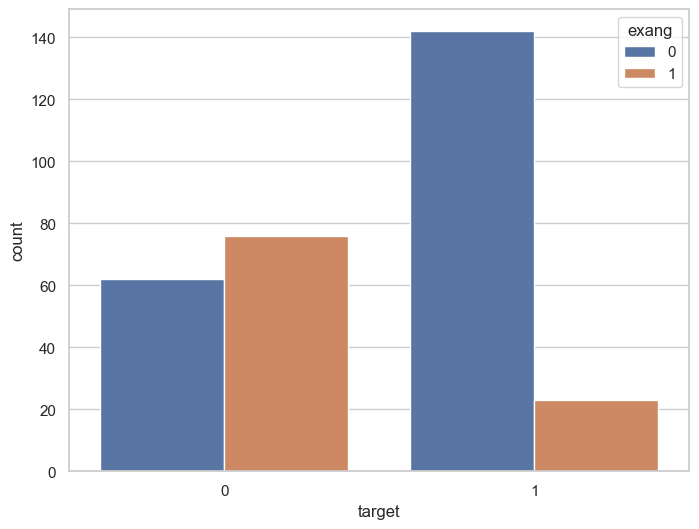

In [25]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="target", hue="exang", data=df)
plt.show()

In [26]:
correlation = df.corr()

In [27]:
correlation['target'].sort_values(ascending=False)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

In [28]:
df['cp'].nunique()

4

In [29]:
df['cp'].value_counts()

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

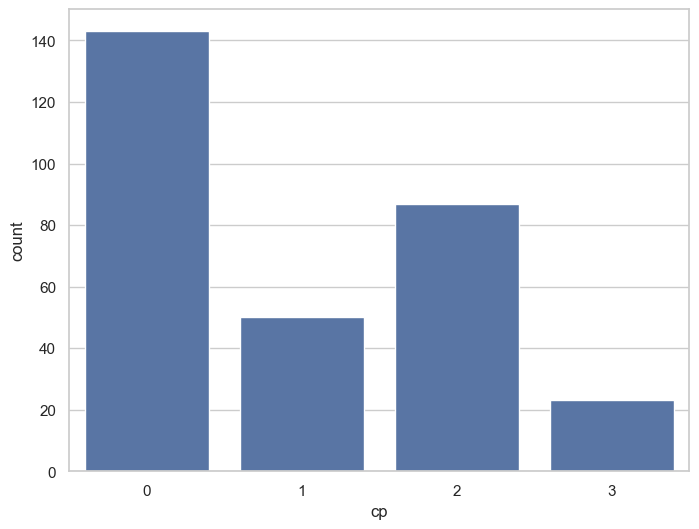

In [30]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="cp", data=df)
plt.show()

In [31]:
df.groupby('cp')['target'].value_counts()

cp  target
0   0         104
    1          39
1   1          41
    0           9
2   1          69
    0          18
3   1          16
    0           7
Name: count, dtype: int64

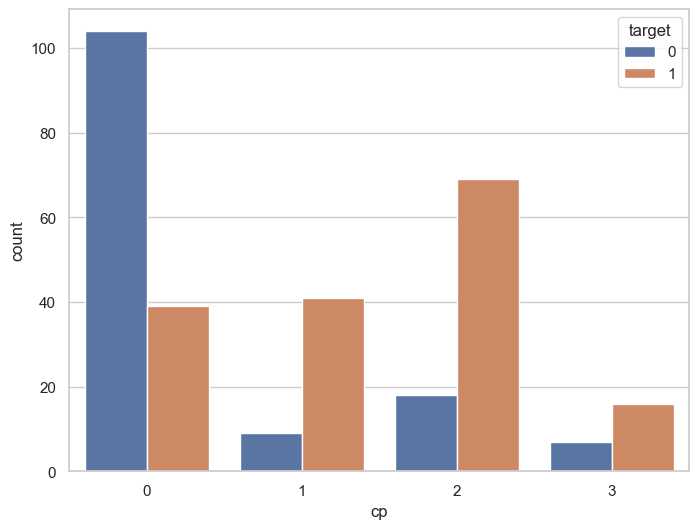

In [32]:
f, ax = plt.subplots(figsize=(8, 6)) #chest pain
ax = sns.countplot(x="cp", hue="target", data=df)
plt.show()

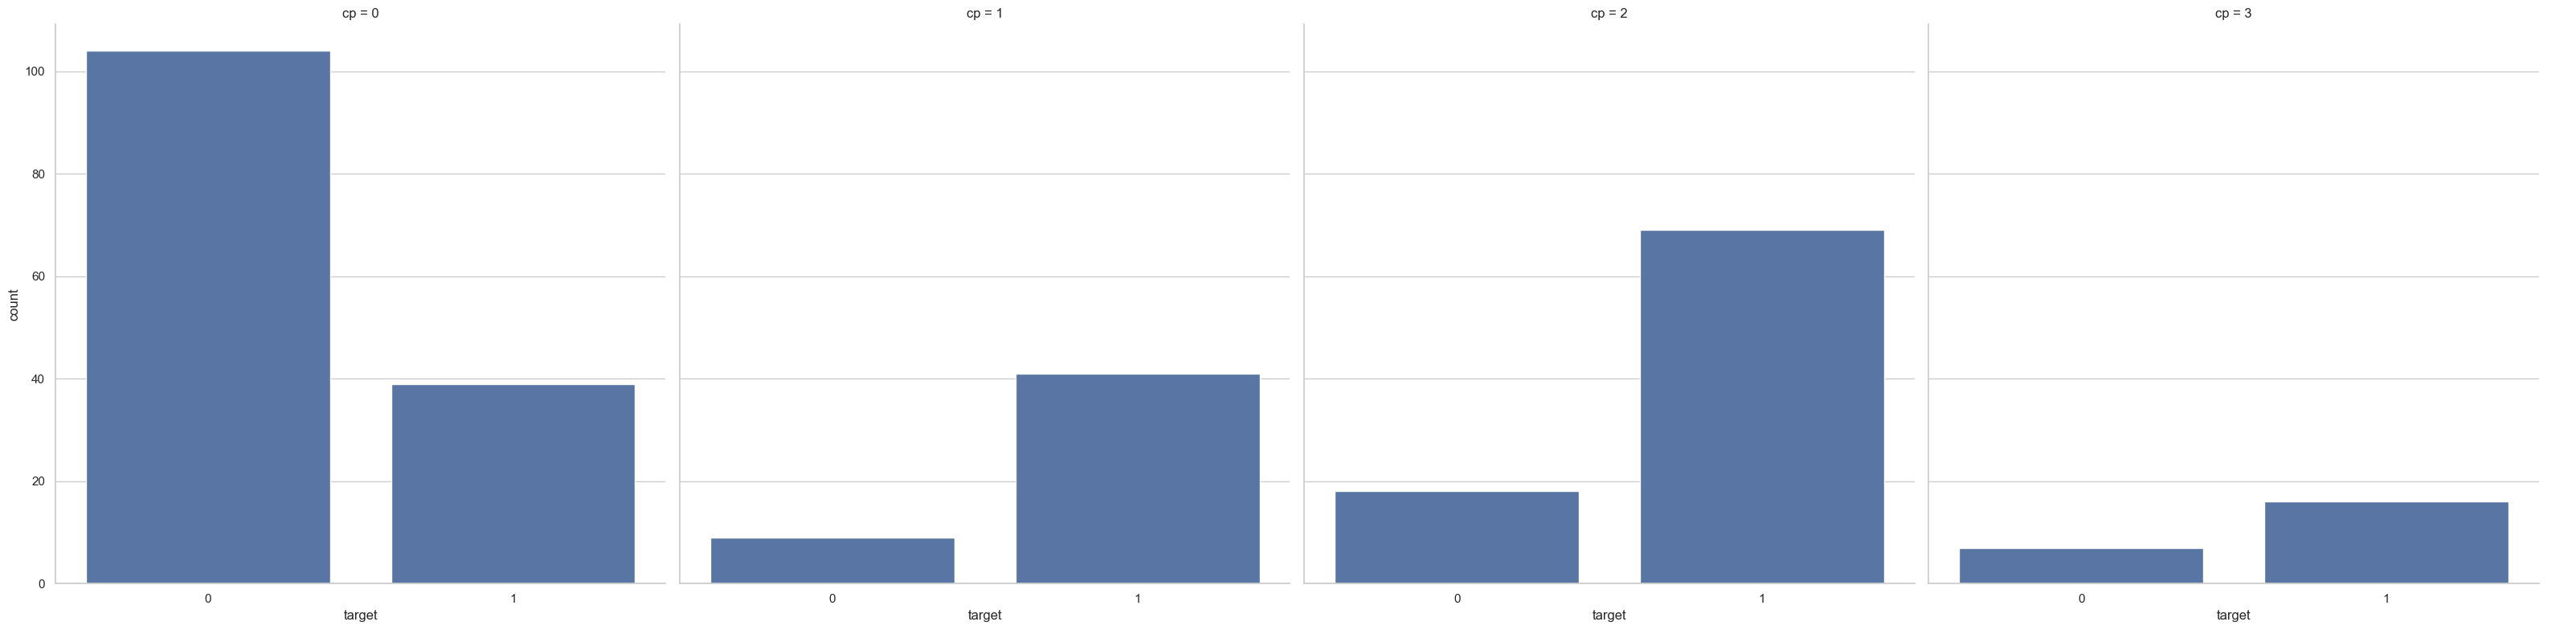

In [33]:
ax = sns.catplot(x="target", col="cp", data=df, kind="count", height=8, aspect=1)

In [34]:
df['thalach'].nunique()

91

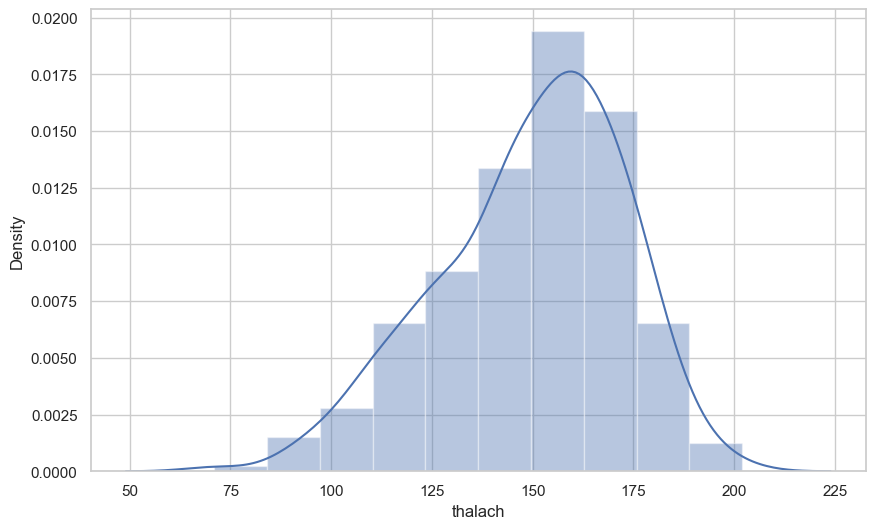

In [35]:
f, ax = plt.subplots(figsize=(10,6))
x = df['thalach']
ax = sns.distplot(x, bins=10)
plt.show()

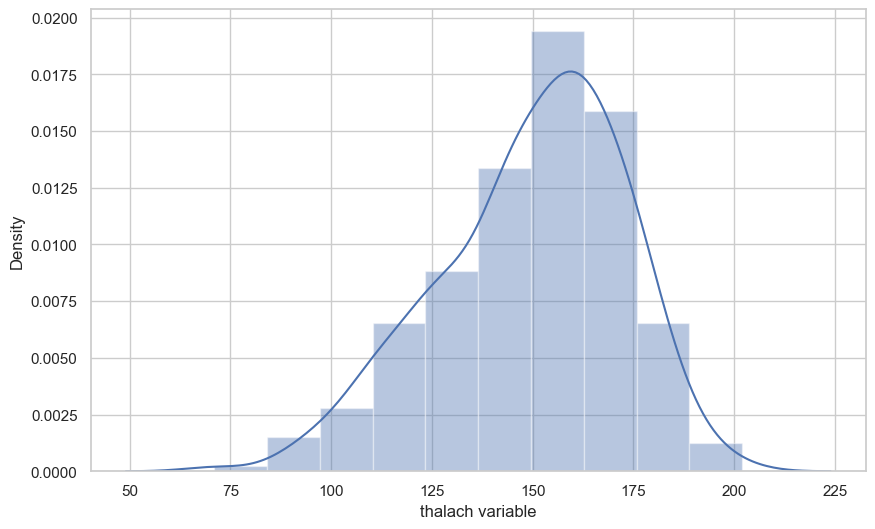

In [36]:
f, ax = plt.subplots(figsize=(10,6))
x = df['thalach']
x = pd.Series(x, name="thalach variable")
ax = sns.distplot(x, bins=10)
plt.show()

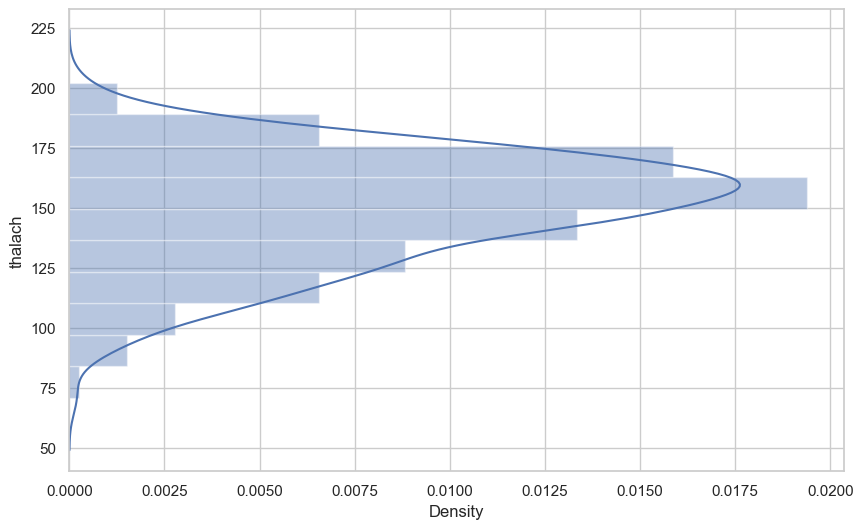

In [37]:
f, ax = plt.subplots(figsize=(10,6))
x = df['thalach']
ax = sns.distplot(x, bins=10, vertical=True)
plt.show()

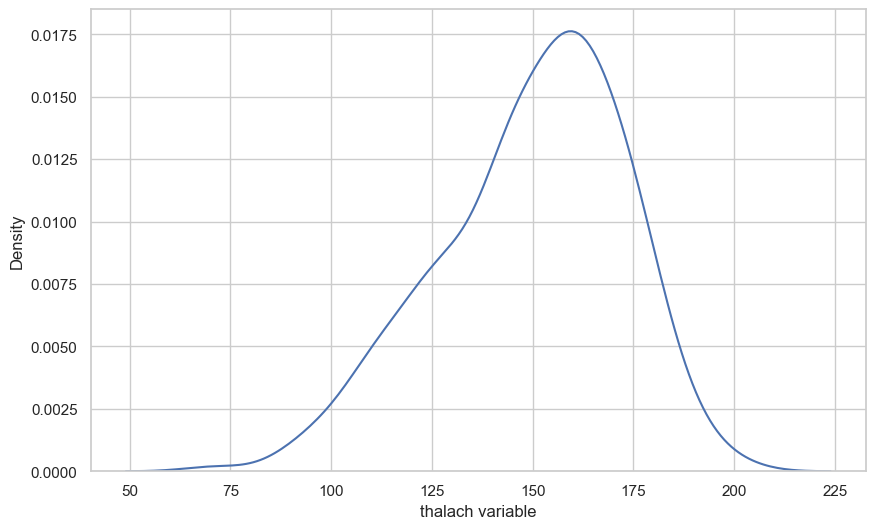

In [38]:
f, ax = plt.subplots(figsize=(10,6))
x = df['thalach']
x = pd.Series(x, name="thalach variable")
ax = sns.kdeplot(x)
plt.show()

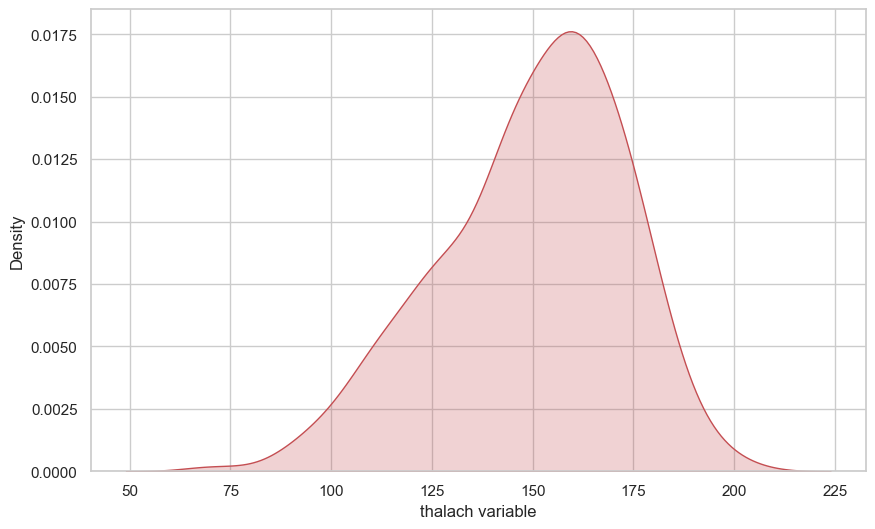

In [39]:
f, ax = plt.subplots(figsize=(10,6))
x = df['thalach']
x = pd.Series(x, name="thalach variable")
ax = sns.kdeplot(x, shade=True, color='r')
plt.show()

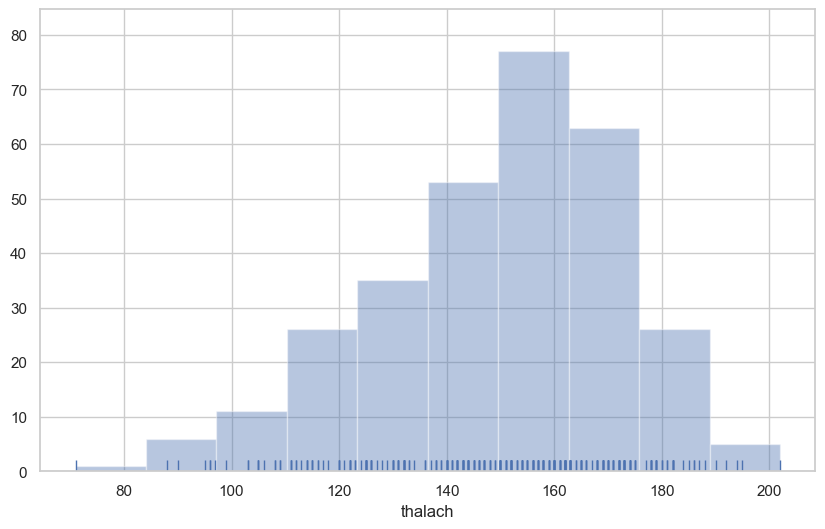

In [40]:
f, ax = plt.subplots(figsize=(10,6))
x = df['thalach']
ax = sns.distplot(x, kde=False, rug=True, bins=10)
plt.show()

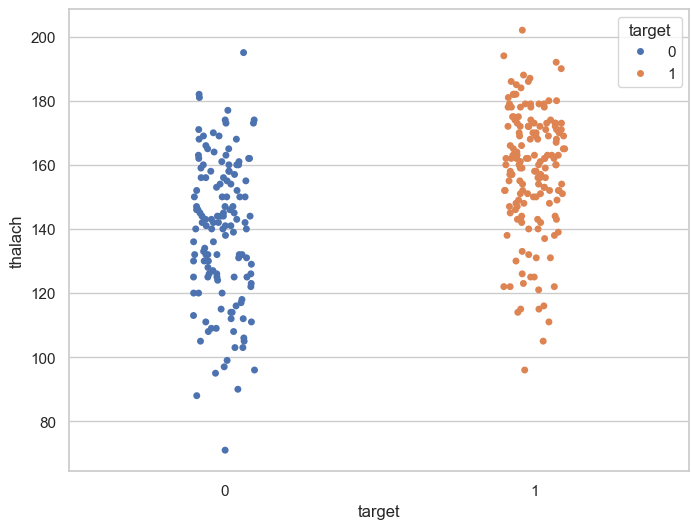

In [41]:
f, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(x="target", y="thalach", data=df,hue = "target")
plt.show()

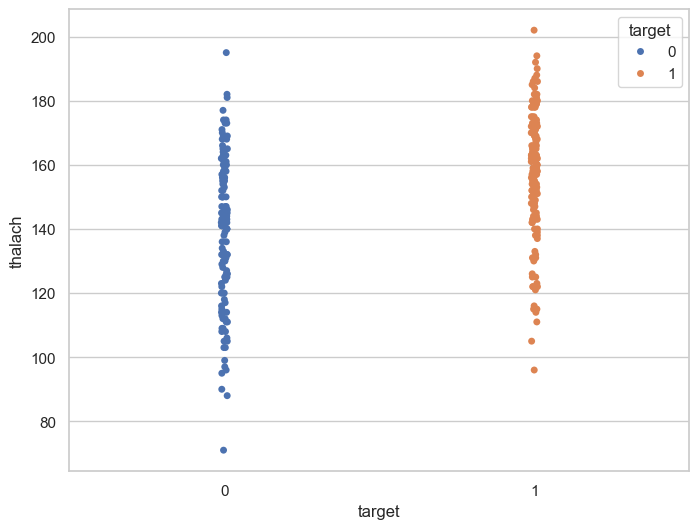

In [42]:
f, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(x="target", y="thalach", data=df, jitter = 0.01,hue = "target")
plt.show()

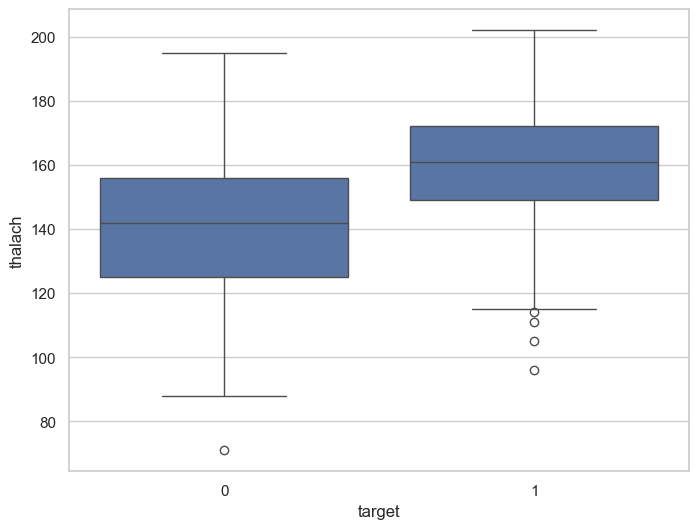

In [43]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="target", y="thalach", data=df)
plt.show()

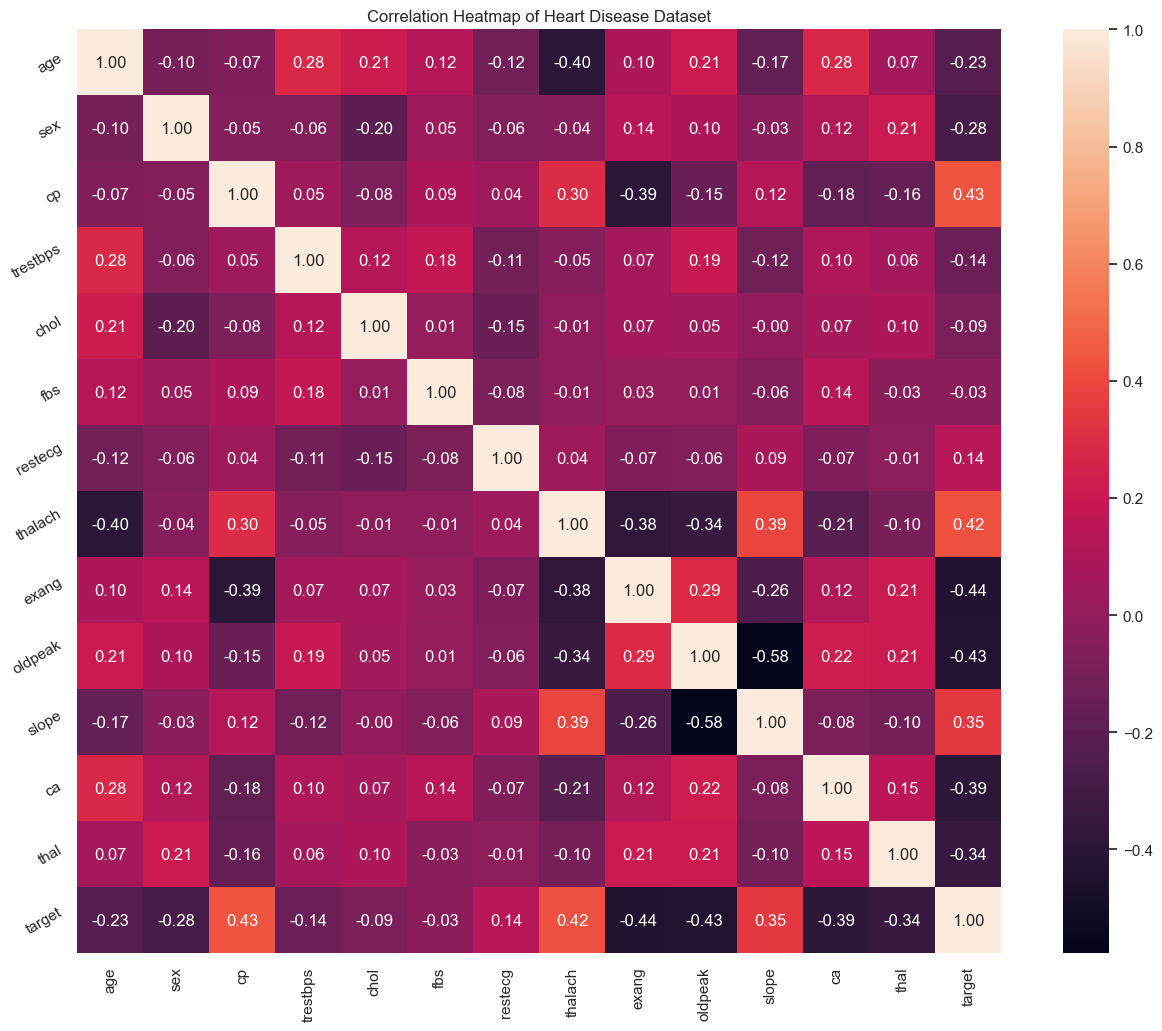

In [44]:
plt.figure(figsize=(16,12))
plt.title('Correlation Heatmap of Heart Disease Dataset')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)           
plt.show()

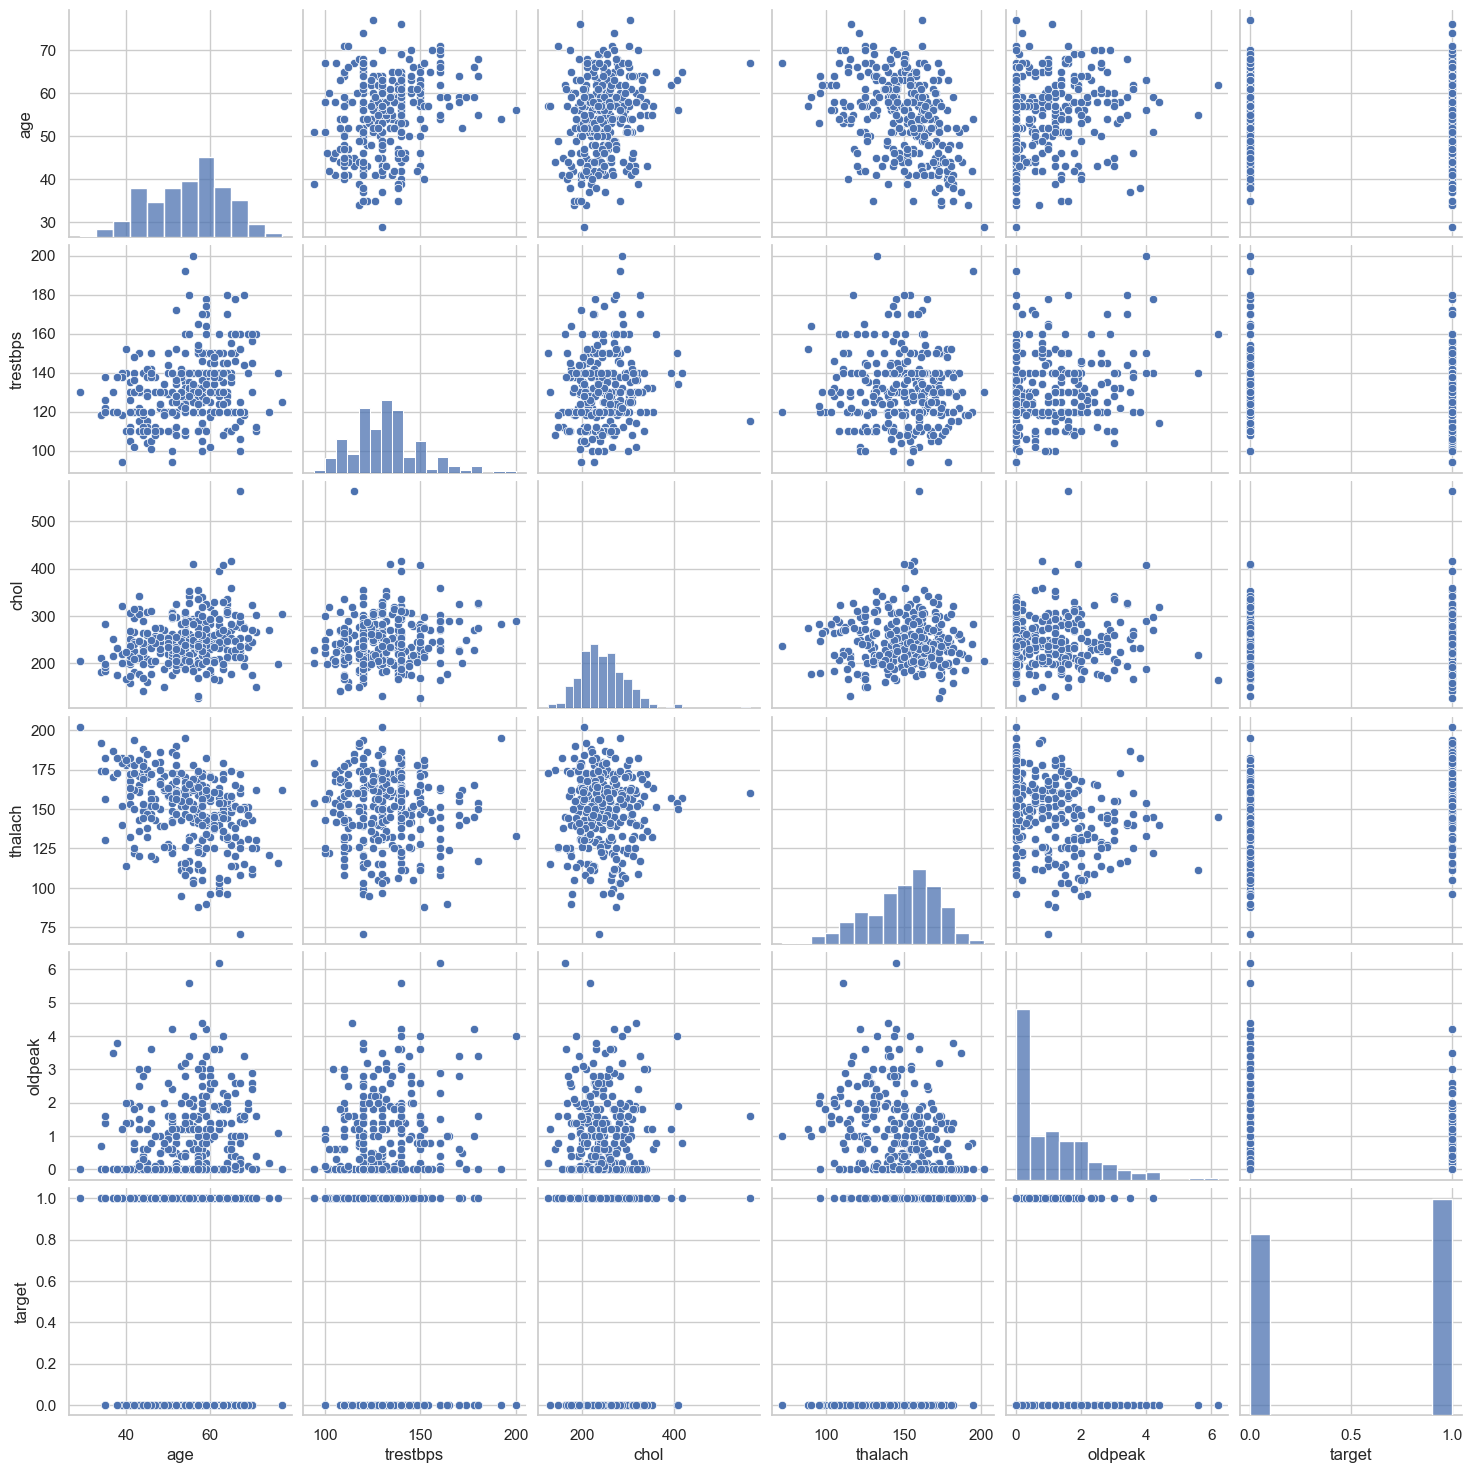

In [45]:
num_var = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target' ]
sns.pairplot(df[num_var], kind='scatter', diag_kind='hist')
plt.show()


In [46]:
df['age'].nunique()

41

In [47]:
df['age'].describe()

count    303.000000
mean      54.366337
std        9.082101
min       29.000000
25%       47.500000
50%       55.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

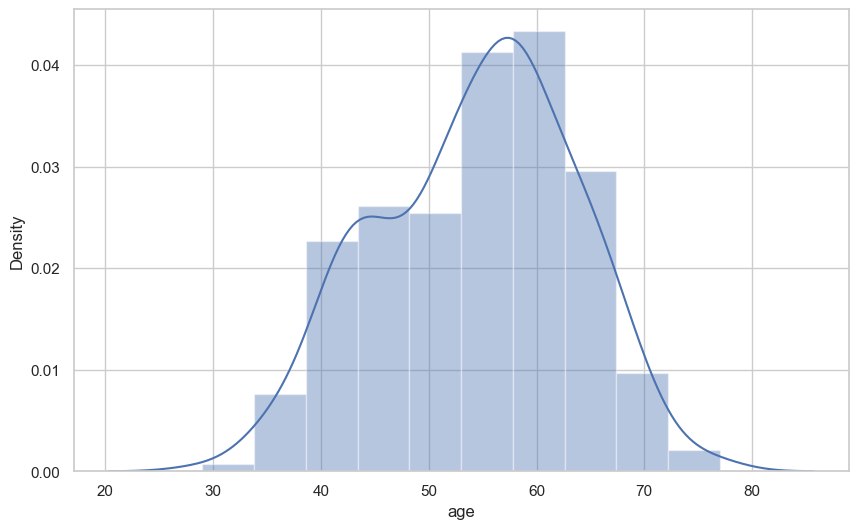

In [48]:
f, ax = plt.subplots(figsize=(10,6))
x = df['age']
ax = sns.distplot(x, bins=10)
plt.show()

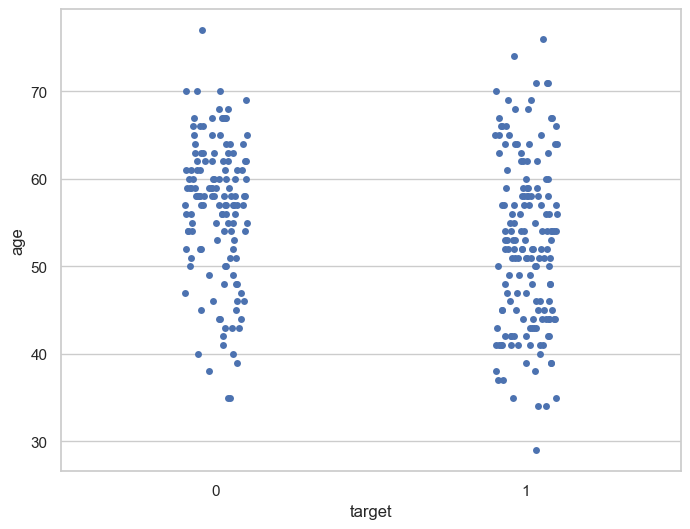

In [49]:
f, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(x="target", y="age", data=df)
plt.show()

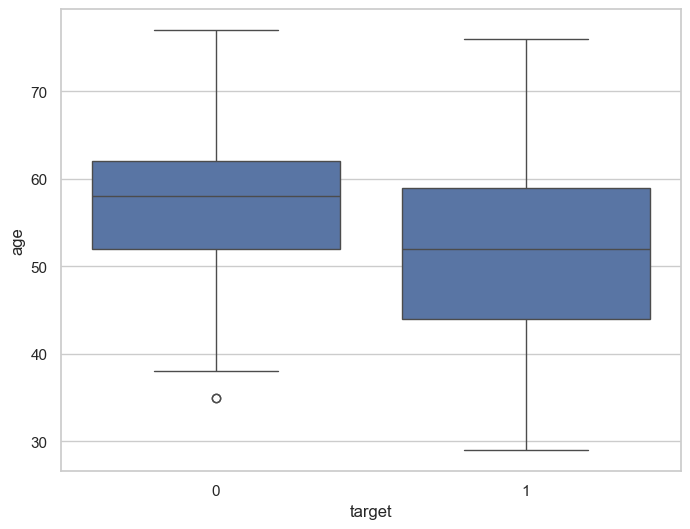

In [50]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="target", y="age", data=df)
plt.show()

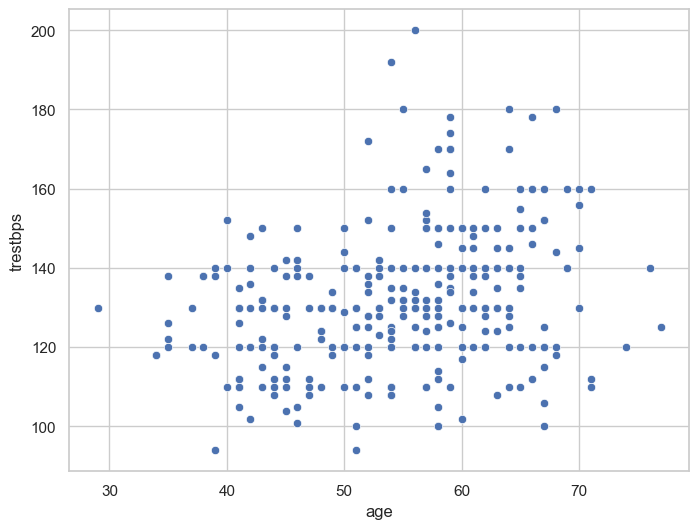

In [51]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.scatterplot(x="age", y="trestbps", data=df)
plt.show()


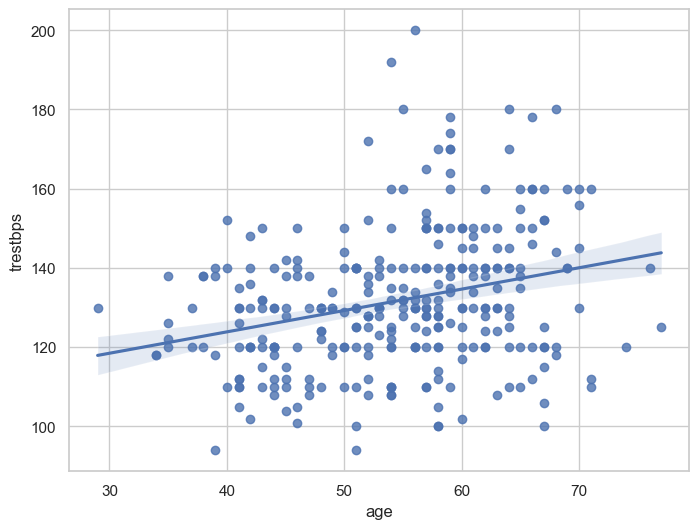

In [52]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.regplot(x="age", y="trestbps", data=df)
plt.show()

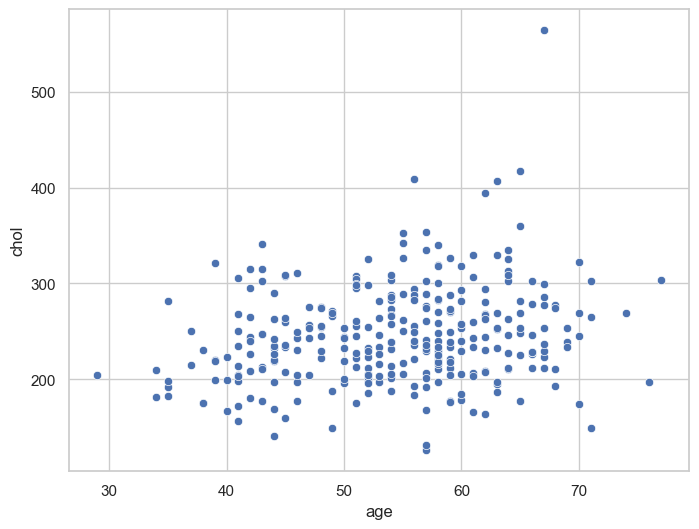

In [53]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.scatterplot(x="age", y="chol", data=df)
plt.show()

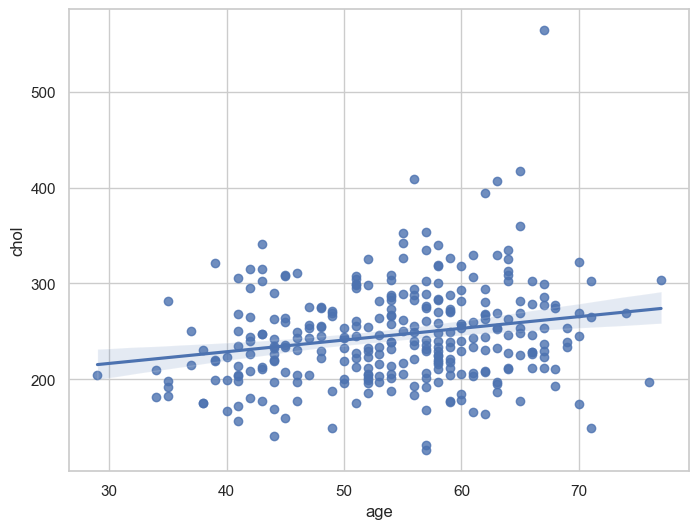

In [54]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.regplot(x="age", y="chol", data=df)
plt.show()

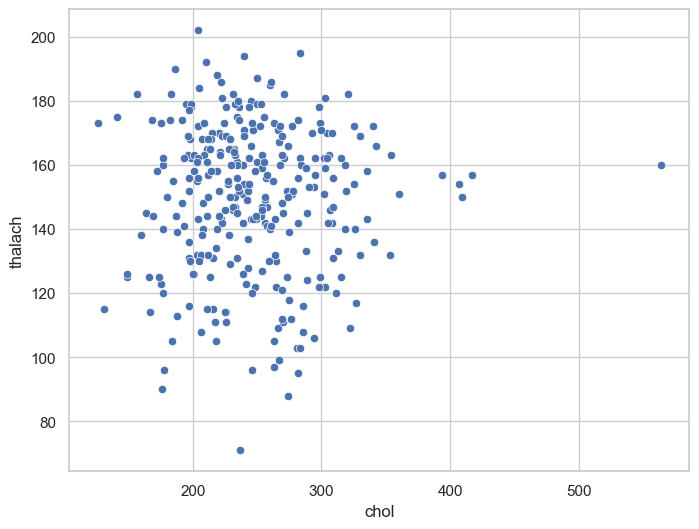

In [55]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.scatterplot(x="chol", y = "thalach", data=df)
plt.show()

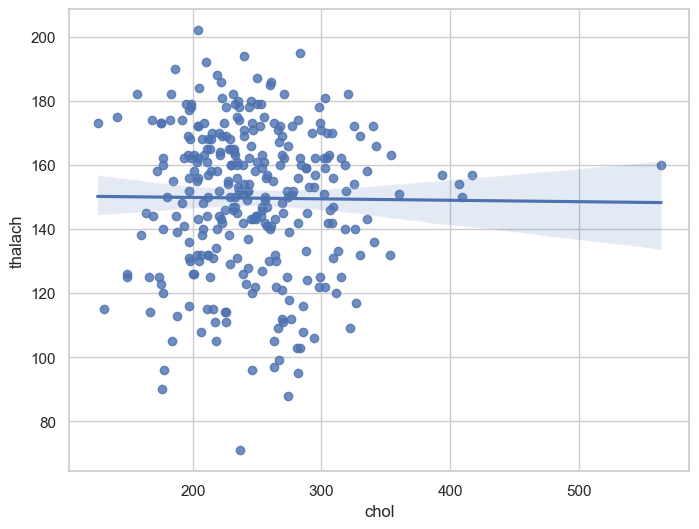

In [56]:
f, ax = plt.subplots(figsize=(8, 6))
ax = sns.regplot(x="chol", y="thalach", data=df)
plt.show()

In [57]:
# check for missing values

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [58]:
#assert that there are no missing values in the dataframe

assert pd.notnull(df).all().all()


In [59]:
#assert all values are greater than or equal to 0

assert (df >= 0).all().all()


In [60]:
df['age'].describe()

count    303.000000
mean      54.366337
std        9.082101
min       29.000000
25%       47.500000
50%       55.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

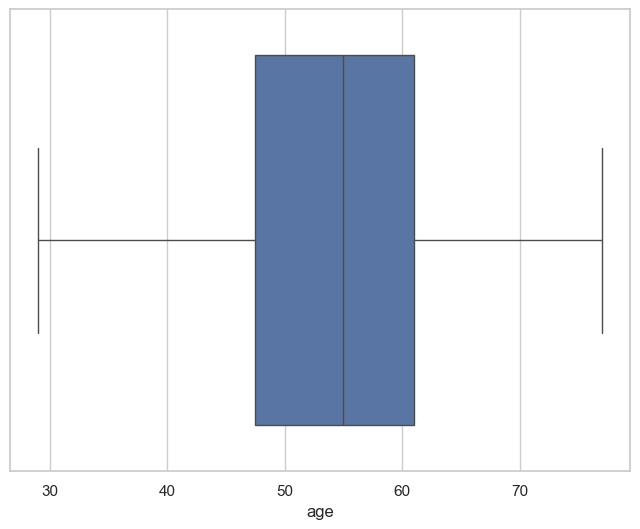

In [61]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x=df["age"])
plt.show()

In [62]:
df['trestbps'].describe()

count    303.000000
mean     131.623762
std       17.538143
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

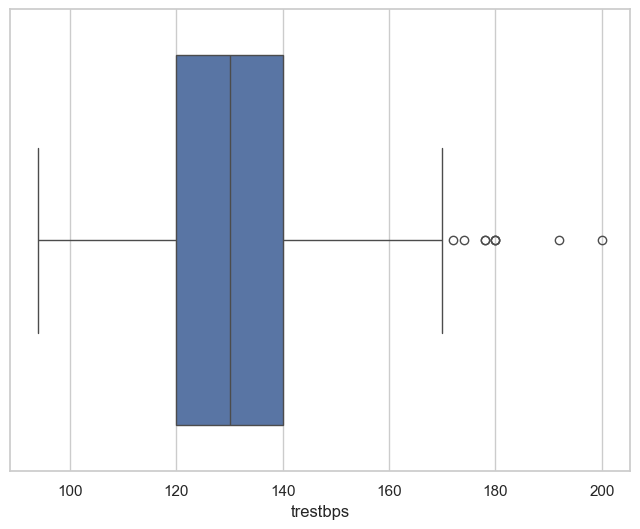

In [63]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x=df["trestbps"])
plt.show()


In [64]:
df['chol'].describe()

count    303.000000
mean     246.264026
std       51.830751
min      126.000000
25%      211.000000
50%      240.000000
75%      274.500000
max      564.000000
Name: chol, dtype: float64

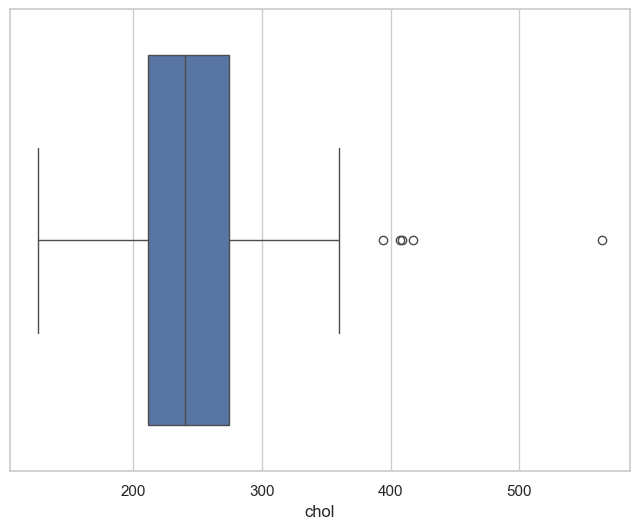

In [65]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x=df["chol"])
plt.show()


In [66]:
df['thalach'].describe()

count    303.000000
mean     149.646865
std       22.905161
min       71.000000
25%      133.500000
50%      153.000000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64

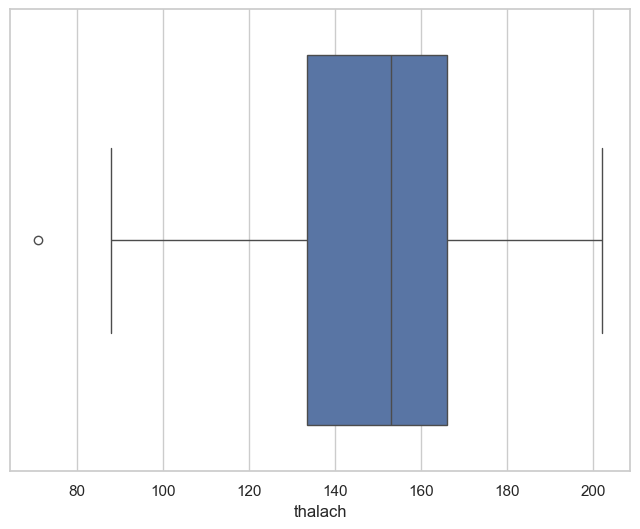

In [67]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x=df["thalach"])
plt.show()

In [68]:
df['oldpeak'].describe()

count    303.000000
mean       1.039604
std        1.161075
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64

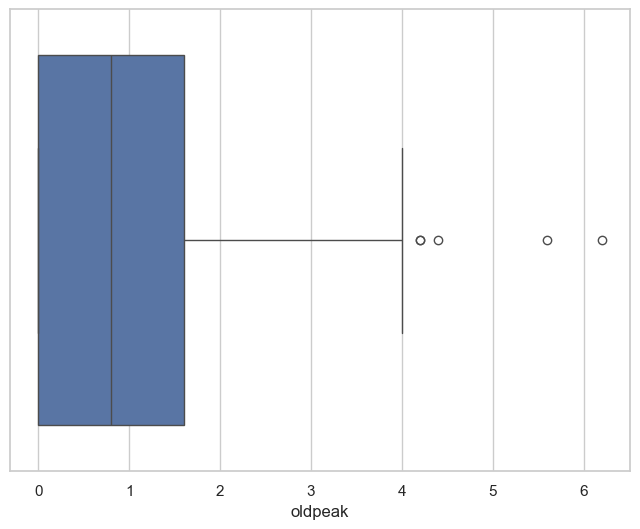

In [69]:
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x=df["oldpeak"])
plt.show()


In [70]:
# Conclusion
'''So, friends, our EDA journey has come to an end.

In this kernel, we have explored the heart disease dataset. In this kernel, we have implemented many of the strategies presented in the book Think Stats - Exploratory Data Analysis in Python by Allen B Downey . The feature variable of interest is `target` variable. We have analyzed it alone and check its interaction with other variables. We have also discussed how to detect missing data and outliers.

I hope you like this kernel on EDA journey.

Thanks'''

'So, friends, our EDA journey has come to an end.\n\nIn this kernel, we have explored the heart disease dataset. In this kernel, we have implemented many of the strategies presented in the book Think Stats - Exploratory Data Analysis in Python by Allen B Downey . The feature variable of interest is `target` variable. We have analyzed it alone and check its interaction with other variables. We have also discussed how to detect missing data and outliers.\n\nI hope you like this kernel on EDA journey.\n\nThanks'

In [71]:
# Deep Leaning Model

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [72]:
df = pd.read_csv(r'D:\Data Science Full Stack\02 septmber\7\5th,6th\5th,6th\EDA_project\heart.csv')

In [73]:
import torch
print(torch.__version__)

2.12.0+cpu


In [74]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.12.0+cpu
CUDA Available: False


In [75]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [76]:
import torch
print(torch.__version__)

2.12.0+cpu


In [77]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

In [78]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [79]:
df = pd.read_csv(r'D:\Data Science Full Stack\02 septmber\7\5th,6th\5th,6th\EDA_project\heart.csv')

if 'id' in df.columns:
    df = df.drop('id', axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [80]:
TARGET_COLUMN = 'target'

In [81]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [82]:
# ==========================
# FEATURES & TARGET
# ==========================

X = df.drop('target', axis=1)  
y = df['target']


In [83]:
# ==========================
# SCALING
# ==========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [84]:
# ==========================
# DATASET
# ==========================

class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y.values)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = HeartDataset(X_train, y_train)
test_dataset = HeartDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [85]:
# ==========================
# MODEL
# ==========================

class HeartANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.layers = nn.Sequential(
    nn.Linear(input_dim,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),

    nn.Linear(128,64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Dropout(0.3),

    nn.Linear(64,32),
    nn.ReLU(),

    nn.Linear(32,1)
)

    def forward(self, x):
        return self.layers(x)


In [86]:
# ==========================
# SETUP
# ==========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HeartANN(X_train.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)


In [87]:
# ==========================

# TRAINING

# ==========================



epochs = 150



for epoch in range(epochs):



    model.train()

    total_loss = 0



    for X_batch, y_batch in train_loader:



        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)



        optimizer.zero_grad()



        outputs = model(X_batch).squeeze()



        loss = criterion(outputs, y_batch)



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    print(

        f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}"

    )



Epoch 1/150 | Loss: 0.6754
Epoch 2/150 | Loss: 0.5887
Epoch 3/150 | Loss: 0.5473
Epoch 4/150 | Loss: 0.4980
Epoch 5/150 | Loss: 0.5027
Epoch 6/150 | Loss: 0.4341
Epoch 7/150 | Loss: 0.4532
Epoch 8/150 | Loss: 0.4147
Epoch 9/150 | Loss: 0.4591
Epoch 10/150 | Loss: 0.4056
Epoch 11/150 | Loss: 0.3794
Epoch 12/150 | Loss: 0.3326
Epoch 13/150 | Loss: 0.3974
Epoch 14/150 | Loss: 0.3256
Epoch 15/150 | Loss: 0.3917
Epoch 16/150 | Loss: 0.3702
Epoch 17/150 | Loss: 0.3066
Epoch 18/150 | Loss: 0.3006
Epoch 19/150 | Loss: 0.3275
Epoch 20/150 | Loss: 0.3012
Epoch 21/150 | Loss: 0.3526
Epoch 22/150 | Loss: 0.3669
Epoch 23/150 | Loss: 0.2667
Epoch 24/150 | Loss: 0.3380
Epoch 25/150 | Loss: 0.3058
Epoch 26/150 | Loss: 0.2839
Epoch 27/150 | Loss: 0.3521
Epoch 28/150 | Loss: 0.3581
Epoch 29/150 | Loss: 0.2515
Epoch 30/150 | Loss: 0.3182
Epoch 31/150 | Loss: 0.3189
Epoch 32/150 | Loss: 0.2705
Epoch 33/150 | Loss: 0.2683
Epoch 34/150 | Loss: 0.2653
Epoch 35/150 | Loss: 0.2133
Epoch 36/150 | Loss: 0.2827
E

In [88]:
# ==========================
# EVALUATION
# ==========================

model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch).squeeze()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.numpy())

In [89]:
# ==========================================
# ACCURACY
# ==========================================

acc = accuracy_score(actuals, predictions)

print("\nAccuracy:", acc)


Accuracy: 0.7704918032786885


In [90]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")

print(
    classification_report(
        actuals,
        predictions
    )
)


Classification Report:

              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74        28
         1.0       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [91]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(actuals, predictions)

print("Confusion Matrix")
print(cm)


Confusion Matrix
[[20  8]
 [ 6 27]]


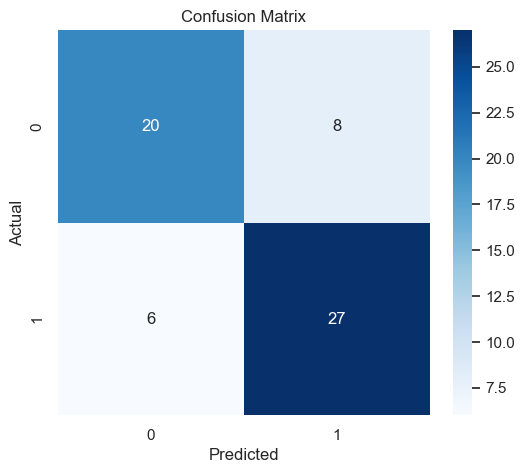

In [92]:
# ==========================================
# CONFUSION MATRIX PLOT
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix

| Actual / Predicted | No Heart Disease | Heart Disease |
| ------------------ | ---------------- | ------------- |
| No Heart Disease   | 20               | 8             |
| Heart Disease      | 6                | 27            |

## Interpretation

* True Negatives (TN) = 20
  Correctly predicted patients without heart disease.

* False Positives (FP) = 8
  Predicted heart disease, but the patient was actually healthy.

* False Negatives (FN) = 6
  Predicted healthy, but the patient actually had heart disease.

* True Positives (TP) = 27
  Correctly predicted patients with heart disease.

## Accuracy Calculation

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Accuracy = (27 + 20) / (27 + 20 + 8 + 6)

Accuracy = 47 / 61

Accuracy = 77.05%

The confusion matrix corresponds to an overall accuracy of 77.05%, indicating that the model correctly classified approximately 77 out of every 100 patients.


In [93]:
# ==========================
# RESULTS
# ==========================

print("\nAccuracy:", accuracy_score(actuals, predictions))

print("\nClassification Report:\n")
print(classification_report(actuals, predictions))


Accuracy: 0.7704918032786885

Classification Report:

              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74        28
         1.0       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [94]:
# ==========================================
# SAVE MODEL
# ==========================================

torch.save(
    model.state_dict(),
    "heart_disease_model.pth"
)

print("\nModel saved successfully!")


Model saved successfully!


# Results of Deep Learning Project on Heart Disease Dataset

## Performance Summary

| Metric    | Class 0 | Class 1 |
| --------- | ------- | ------- |
| Precision | 0.77    | 0.77    |
| Recall    | 0.71    | 0.82    |
| F1-Score  | 0.74    | 0.79    |

### Overall Accuracy

Accuracy = 77.05%

This means the model correctly predicts approximately 77 out of every 100 patients.

## Interpretation

### Recall for Heart Disease (Class 1) = 82%

The model successfully identifies most patients who have heart disease. This is particularly important in healthcare because failing to detect a patient with heart disease can have serious consequences.

### Precision for Heart Disease (Class 1) = 77%

When the model predicts that a patient has heart disease, it is correct 77% of the time.

### F1-Score for Heart Disease (Class 1) = 79%

The F1-score indicates a good balance between precision and recall, demonstrating that the model performs consistently in detecting heart disease cases.

## Conclusion

A Deep Learning-based Artificial Neural Network (ANN) was developed using PyTorch for heart disease prediction. After preprocessing, feature scaling, and training for multiple epochs, the model achieved an overall accuracy of 77.05% on the test dataset. The model demonstrated strong recall (82%) for identifying heart disease patients, making it a useful predictive model for healthcare risk assessment. The results indicate that Deep Learning can effectively classify heart disease risk and may be further improved through hyperparameter tuning and advanced ensemble techniques.


# Heart Disease / Cardiovascular Disease Analysis Using Deep Learning

A Deep Learning-based Artificial Neural Network (ANN) was developed using PyTorch to predict the presence of heart disease. The dataset was preprocessed using feature scaling and divided into training and testing subsets using an 80:20 ratio.

The ANN architecture consisted of multiple fully connected hidden layers with ReLU activation functions, Batch Normalization, and Dropout regularization to improve generalization and reduce overfitting. The model was trained using the Adam optimizer and Binary Cross Entropy Loss function.

After training, the model achieved an overall accuracy of **77.05%** on the test dataset. The classification report showed a precision of **77%**, recall of **82%**, and F1-score of **79%** for the heart disease class.

The high recall score indicates that the model is effective in identifying patients with heart disease, which is particularly important in healthcare applications where missing a positive case can have serious consequences. The precision score of 77% demonstrates that the majority of patients predicted as having heart disease were correctly classified.

The confusion matrix results showed:

* True Negatives (TN) = 20
* False Positives (FP) = 8
* False Negatives (FN) = 6
* True Positives (TP) = 27

These results indicate that the model successfully identified most heart disease cases while maintaining balanced overall performance.

In conclusion, the Deep Learning model demonstrated satisfactory predictive capability for heart disease classification, achieving an accuracy of 77.05% and strong recall performance. The results suggest that Artificial Neural Networks can effectively classify heart disease risk using clinical patient attributes and may be further improved through hyperparameter tuning, feature engineering, and advanced ensemble learning techniques.
